In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import joblib
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
dataset_path = '/content/advertising.csv'

try:
    df = pd.read_csv(dataset_path)
    print(f"Dataset '{dataset_path}' loaded successfully.")
except FileNotFoundError:
    print(f"Error: Dataset '{dataset_path}' not found.")
    df = None

if df is not None:
    print("\n- First 5 rows-")
    display(df.head())

    print("\n-Last 5 rows-")
    display(df.tail())

    print("\n-Dataset Shape-")
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

    print("\n-Dataset Information-")
    df.info()

    print("\n-Data Types-")
    print(df.dtypes)

    print("\n-Column Names-")
    print(df.columns.tolist())

Dataset '/content/advertising.csv' loaded successfully.

- First 5 rows-


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9



-Last 5 rows-


,TV,Radio,Newspaper,Sales
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5
199,232.1,8.6,8.7,18.4



-Dataset Shape-
Rows: 200, Columns: 4

-Dataset Information-
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB

-Data Types-
TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

-Column Names-
['TV', 'Radio', 'Newspaper', 'Sales']


In [ ]:
print("-Missing Values-")
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Percentage': missing_percentage})
display(missing_df[missing_df['Missing Count'] > 0])

if missing_df[missing_df['Missing Count'] > 0].empty:
    print("No missing values found in the dataset.")
else:
    print("Missing values detected.")

-Missing Values-


,Missing Count,Percentage


No missing values found in the dataset.


In [ ]:
print("-Duplicate Records-")
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

if duplicate_rows == 0:
    print("No duplicate rows found in the dataset.")
else:
    print("Duplicate rows detected.")

-Duplicate Records-
Number of duplicate rows: 0
No duplicate rows found in the dataset.


In [ ]:
print("-Statistical Summary-")
display(df.describe().T)

-Statistical Summary-


,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
Radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
Newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
Sales,200.0,15.1305,5.283892,1.6,11.000,16.00,19.050,27.0


In [ ]:
print("- Unique Values per Column-")
for column in df.columns:
    unique_count = df[column].nunique()
    print(f"Column '{column}': {unique_count} unique values")
    if unique_count < 20: # Display unique values if there are few
        print(f"Unique values: {df[column].unique()}")
    print("\n")

- Unique Values per Column-
Column 'TV': 190 unique values


Column 'Radio': 167 unique values


Column 'Newspaper': 172 unique values


Column 'Sales': 121 unique values




-Correlation Matrix-


,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.901208
Radio,0.054809,1.000000,0.354104,0.349631
Newspaper,0.056648,0.354104,1.000000,0.157960
Sales,0.901208,0.349631,0.157960,1.000000


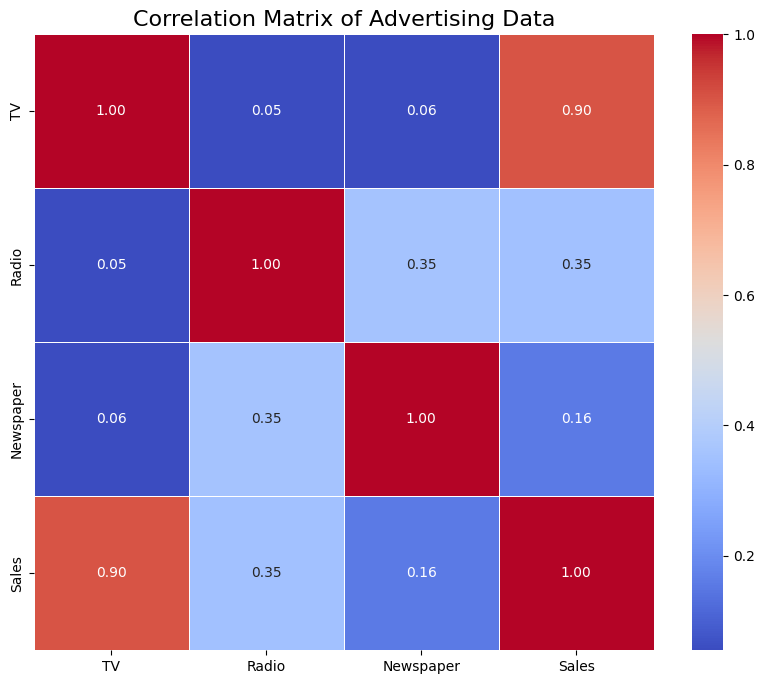

In [ ]:
print("-Correlation Matrix-")
correlation_matrix = df.corr()
display(correlation_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Advertising Data', fontsize=16)
plt.show()

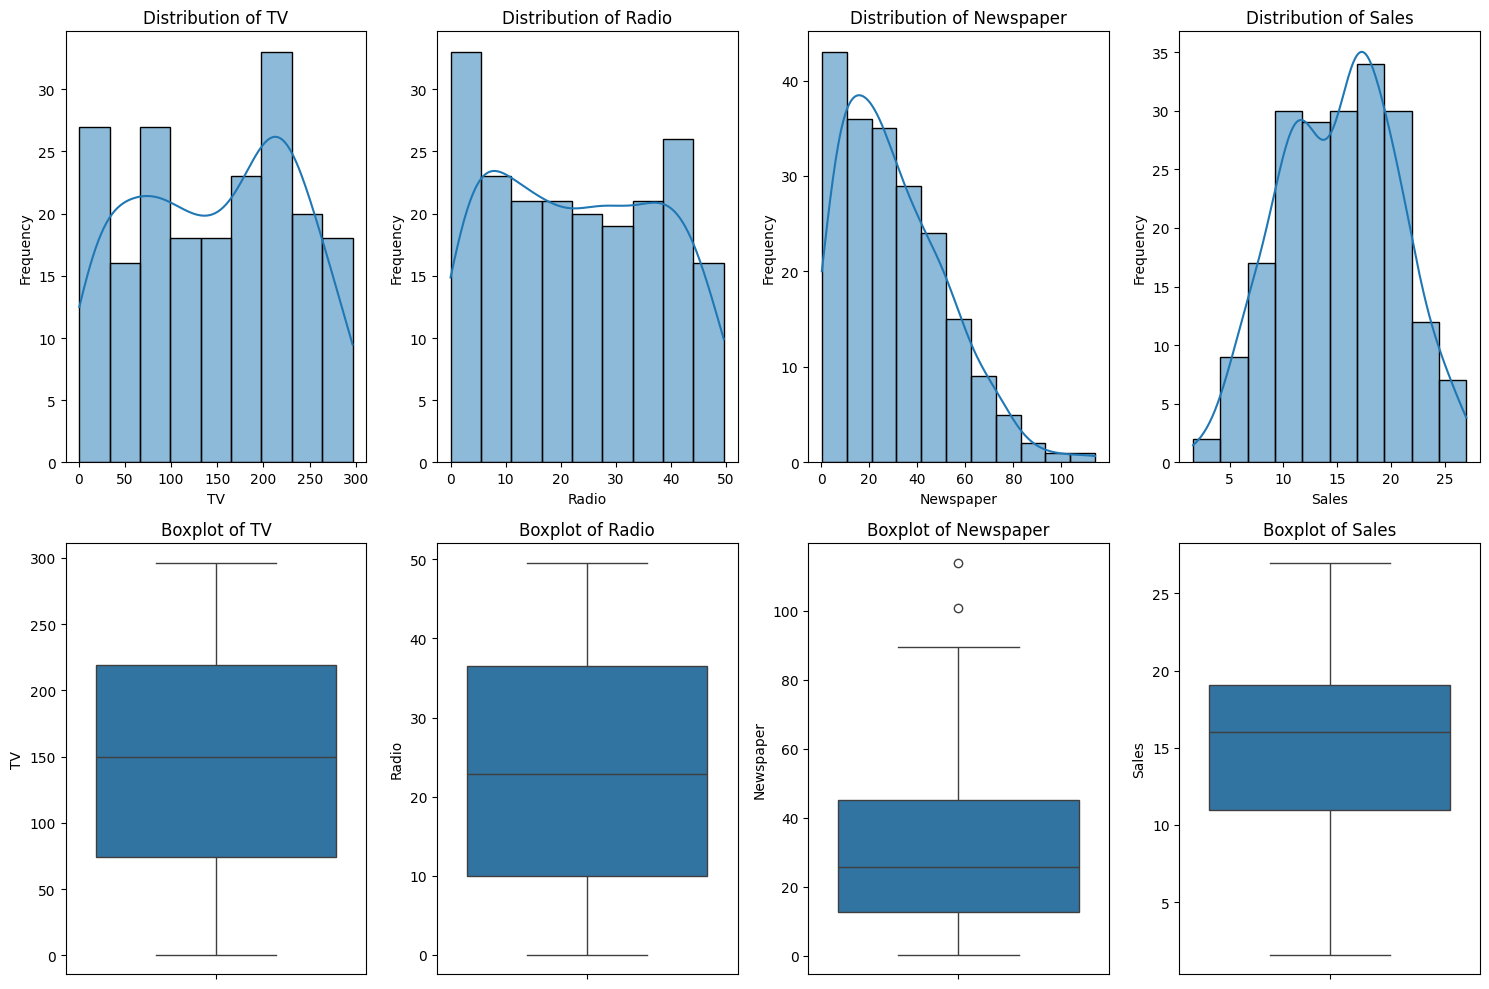

In [ ]:
numerical_features = ['TV', 'Radio', 'Newspaper', 'Sales']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 4, i+1)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

    plt.subplot(2, 4, i+1+4)
    sns.boxplot(y=df[feature])
    plt.title(f'Boxplot of {feature}')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

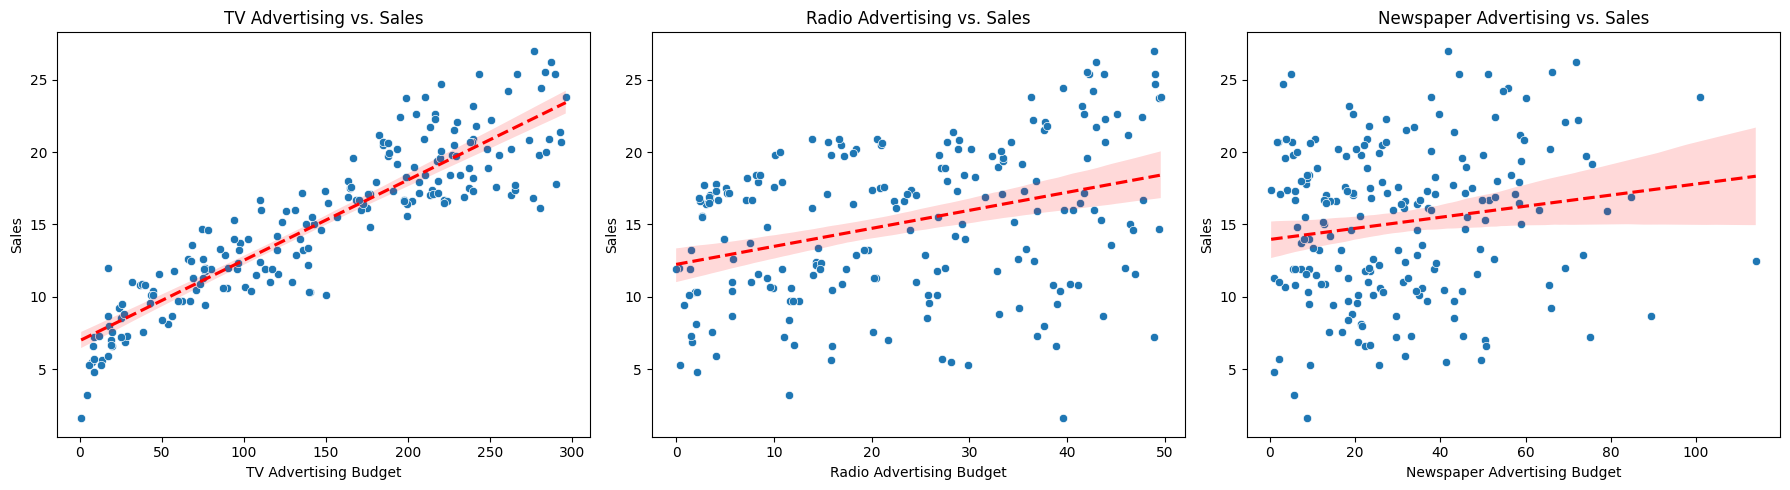

In [ ]:
plt.figure(figsize=(18, 5))

# TV vs Sales
plt.subplot(1, 3, 1)
sns.scatterplot(x='TV', y='Sales', data=df)
sns.regplot(x='TV', y='Sales', data=df, scatter=False, color='red', line_kws={'linestyle':'--'})
plt.title('TV Advertising vs. Sales')
plt.xlabel('TV Advertising Budget')
plt.ylabel('Sales')

# Radio vs Sales
plt.subplot(1, 3, 2)
sns.scatterplot(x='Radio', y='Sales', data=df)
sns.regplot(x='Radio', y='Sales', data=df, scatter=False, color='red', line_kws={'linestyle':'--'})
plt.title('Radio Advertising vs. Sales')
plt.xlabel('Radio Advertising Budget')
plt.ylabel('Sales')

# Newspaper vs Sales
plt.subplot(1, 3, 3)
sns.scatterplot(x='Newspaper', y='Sales', data=df)
sns.regplot(x='Newspaper', y='Sales', data=df, scatter=False, color='red', line_kws={'linestyle':'--'})
plt.title('Newspaper Advertising vs. Sales')
plt.xlabel('Newspaper Advertising Budget')
plt.ylabel('Sales')

plt.tight_layout()
plt.show()

-Pairplot of all features-


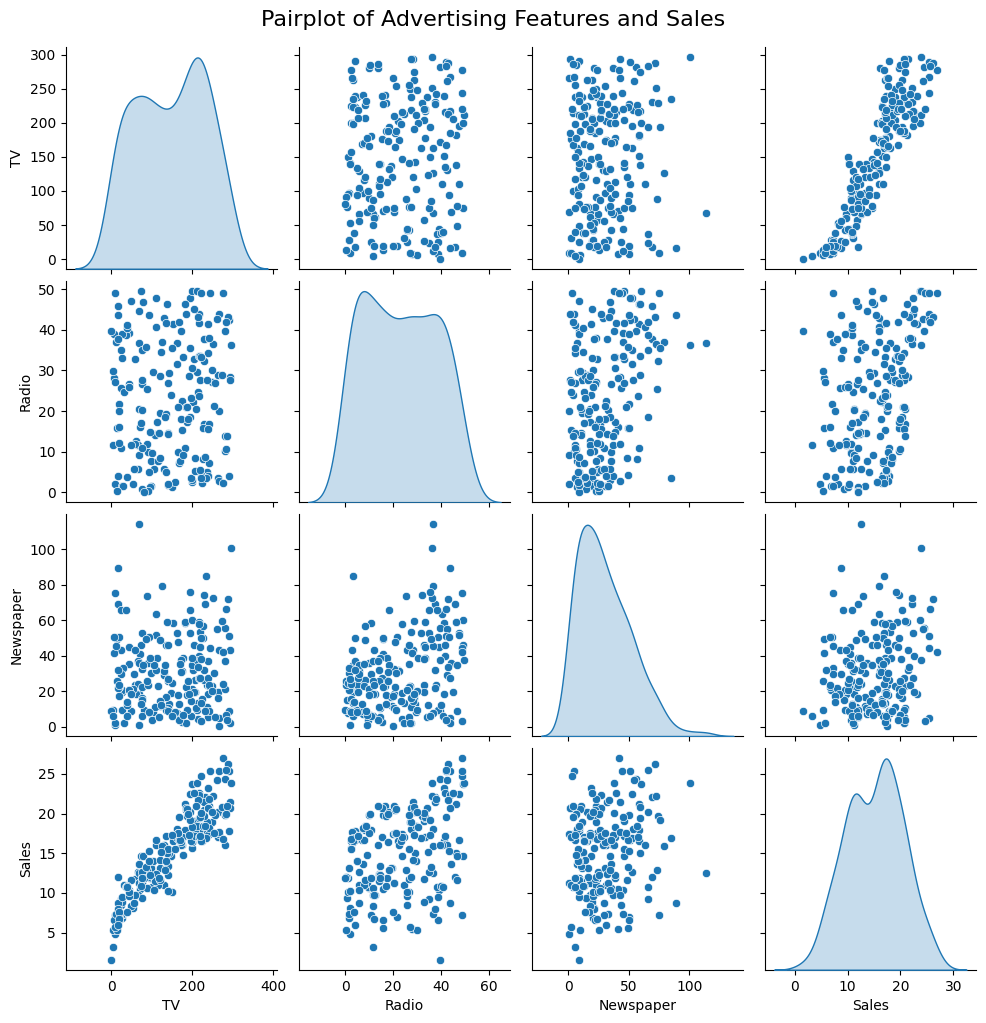

In [ ]:
print("-Pairplot of all features-")
sns.pairplot(df, diag_kind='kde')
plt.suptitle('Pairplot of Advertising Features and Sales', y=1.02, fontsize=16)
plt.show()

In [ ]:
print("Checking for missing values")
if df.isnull().sum().sum() == 0:
    print("No missing values found.")
else:
    print("Missing values detected:")
    display(df.isnull().sum()[df.isnull().sum() > 0])

Checking for missing values
No missing values found.


In [ ]:
print("Checking for duplicate rows")
duplicate_rows_count = df.duplicated().sum()
if duplicate_rows_count == 0:
    print("No duplicate rows found.")
else:
    print(f"{duplicate_rows_count} duplicate rows detected")
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed. New shape:", df.shape)

Checking for duplicate rows
No duplicate rows found.


In [ ]:
print("Current data types:")
display(df.dtypes)


Current data types:


,0
TV,float64
Radio,float64
Newspaper,float64
Sales,float64


-Outlier Handling for Newspaper-

Newspaper Q1: 12.75
Newspaper Q3: 45.10
Newspaper IQR: 32.35
Newspaper Upper Bound: 93.62
Newspaper Lower Bound: -35.78

Detected 2 outliers in 'Newspaper' column. Capping them...
Outliers in 'Newspaper' column have been capped.


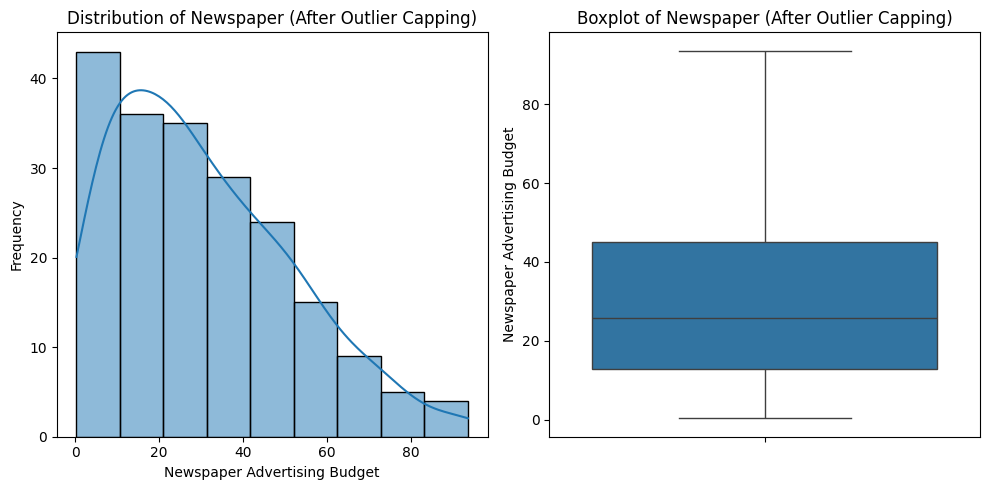


Newspaper feature after outlier handling:


,Newspaper
count,200.000000
mean,30.415750
std,21.316901
min,0.300000
25%,12.750000
50%,25.750000
75%,45.100000
max,93.625000


In [ ]:
print("-Outlier Handling for Newspaper-\n")

Q1 = df['Newspaper'].quantile(0.25)
Q3 = df['Newspaper'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

print(f"Newspaper Q1: {Q1:.2f}")
print(f"Newspaper Q3: {Q3:.2f}")
print(f"Newspaper IQR: {IQR:.2f}")
print(f"Newspaper Upper Bound: {upper_bound:.2f}")
print(f"Newspaper Lower Bound: {lower_bound:.2f}")

outliers = df[(df['Newspaper'] > upper_bound) | (df['Newspaper'] < lower_bound)]

if not outliers.empty:
    print(f"\nDetected {len(outliers)} outliers in 'Newspaper' column. Capping them...")
    # Cap outliers to the upper bound
    df['Newspaper'] = np.where(df['Newspaper'] > upper_bound, upper_bound, df['Newspaper'])
    df['Newspaper'] = np.where(df['Newspaper'] < lower_bound, lower_bound, df['Newspaper'])
    print("Outliers in 'Newspaper' column have been capped.")
else:
    print("\nNo significant outliers detected in 'Newspaper' column based on IQR method.")

# Visualize distribution after capping
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Newspaper'], kde=True)
plt.title('Distribution of Newspaper (After Outlier Capping)')
plt.xlabel('Newspaper Advertising Budget')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Newspaper'])
plt.title('Boxplot of Newspaper (After Outlier Capping)')
plt.ylabel('Newspaper Advertising Budget')

plt.tight_layout()
plt.show()

print("\nNewspaper feature after outlier handling:")
display(df['Newspaper'].describe())

New feature 'Total_Advertising_Spend' created.

First 5 rows with new feature:


,TV,Radio,Newspaper,Sales,Total_Advertising_Spend
0,230.1,37.8,69.2,22.1,337.1
1,44.5,39.3,45.1,10.4,128.9
2,17.2,45.9,69.3,12.0,132.4
3,151.5,41.3,58.5,16.5,251.3
4,180.8,10.8,58.4,17.9,250.0



Correlation of Total_Advertising_Spend with Sales: 0.9257990588078874


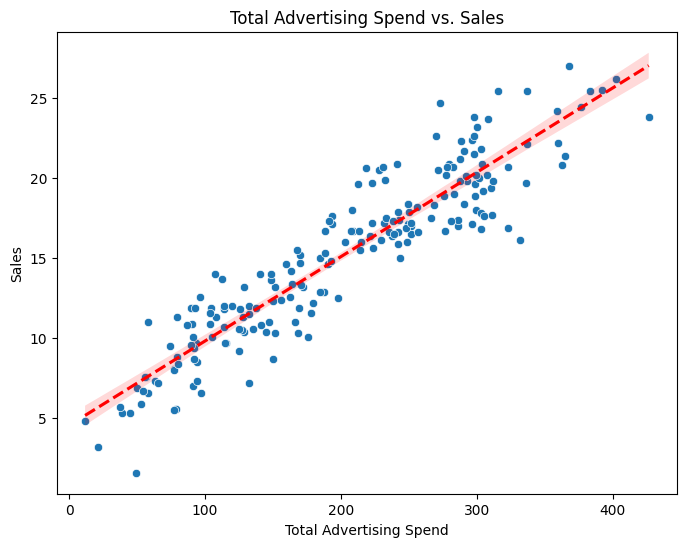

In [ ]:
# Create a new feature: Total Advertising Spend
df['Total_Advertising_Spend'] = df['TV'] + df['Radio'] + df['Newspaper']
print("New feature 'Total_Advertising_Spend' created.")

print("\nFirst 5 rows with new feature:")
display(df.head())

print("\nCorrelation of Total_Advertising_Spend with Sales:", df['Total_Advertising_Spend'].corr(df['Sales']))

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Total_Advertising_Spend', y='Sales', data=df)
sns.regplot(x='Total_Advertising_Spend', y='Sales', data=df, scatter=False, color='red', line_kws={'linestyle':'--'})
plt.title('Total Advertising Spend vs. Sales')
plt.xlabel('Total Advertising Spend')
plt.ylabel('Sales')
plt.show()

-Feature Selection based on Correlation-


,TV,Radio,Newspaper,Sales,Total_Advertising_Spend
TV,1.000000,0.054809,0.059325,0.901208,0.946663
Radio,0.054809,1.000000,0.355953,0.349631,0.292185
Newspaper,0.059325,0.355953,1.000000,0.160959,0.341221
Sales,0.901208,0.349631,0.160959,1.000000,0.925799
Total_Advertising_Spend,0.946663,0.292185,0.341221,0.925799,1.000000


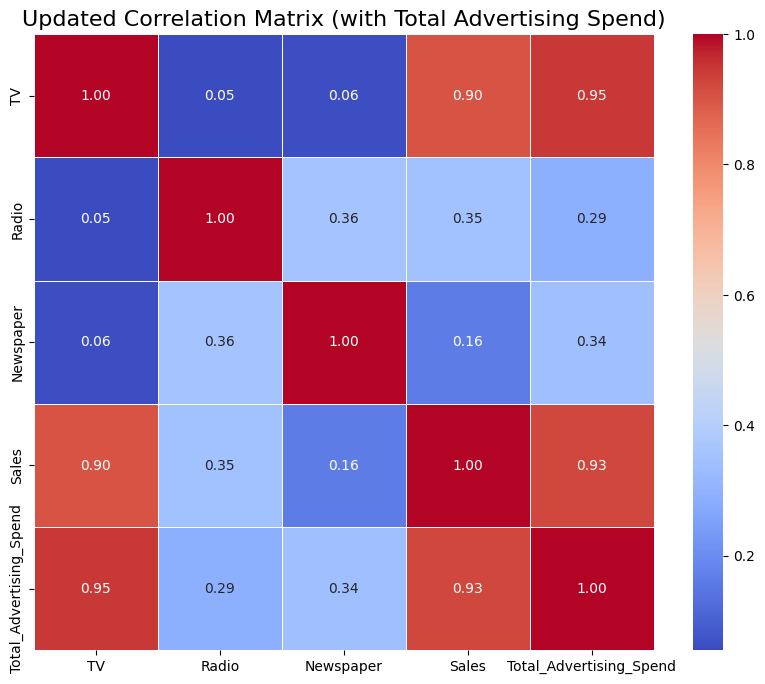

In [ ]:
print("-Feature Selection based on Correlation-")

correlation_matrix_updated = df.corr()
display(correlation_matrix_updated)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_updated, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Updated Correlation Matrix (with Total Advertising Spend)', fontsize=16)
plt.show()

In [ ]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)
print("\nFirst 5 rows of X:")
display(X.head())
print("\nFirst 5 rows of y:")
display(y.head())

Shape of features (X): (200, 3)
Shape of target (y): (200,)

First 5 rows of X:


,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4



First 5 rows of y:


,Sales
0,22.1
1,10.4
2,12.0
3,16.5
4,17.9


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (160, 3)
Shape of X_test: (40, 3)
Shape of y_train: (160,)
Shape of y_test: (40,)


In [ ]:
print("Applying StandardScaler to features")

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Features scaled successfully.")
print("\nFirst 5 rows of scaled X_train:")
display(X_train_scaled.head())

print("\nDescriptive statistics of scaled X_train:")
display(X_train_scaled.describe().T)

Applying StandardScaler to features
Features scaled successfully.

First 5 rows of scaled X_train:


,TV,Radio,Newspaper
79,-0.404248,-1.028237,-0.337960
197,0.320608,-0.919828,-1.167930
38,-1.270511,0.259124,0.258426
24,-1.042359,-0.696233,-0.576514
122,0.879103,-1.387343,-0.710701



Descriptive statistics of scaled X_train:


,count,mean,std,min,25%,50%,75%,max
TV,160.0,-2.942091e-16,1.00314,-1.774345,-0.858769,0.007494,0.817609,1.739424
Radio,160.0,-2.081668e-16,1.00314,-1.549957,-0.884256,-0.113533,0.918049,1.810732
Newspaper,160.0,9.992007e-17,1.00314,-1.471093,-0.846130,-0.213713,0.725595,3.167050


In [ ]:
# Initialize a dictionary to store models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(random_state=42),
    "Lasso Regression": Lasso(random_state=42),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "Extra Trees Regressor": ExtraTreesRegressor(random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42),
    "AdaBoost Regressor": AdaBoostRegressor(random_state=42),
    "K-Nearest Neighbors Regressor": KNeighborsRegressor(),
    "Support Vector Regressor": SVR()
}

# Dictionary to store trained models
trained_models = {}

print("Training various regression models")

for name, model in models.items():
    print(f"\nTraining {name}")
    if name in ["Linear Regression", "Ridge Regression", "Lasso Regression", "K-Nearest Neighbors Regressor", "Support Vector Regressor"]:
        # These models generally benefit from scaled data
        model.fit(X_train_scaled, y_train)
    else:
        # Tree-based models are less sensitive to scaling
        model.fit(X_train, y_train)

    trained_models[name] = model
    print(f"{name} trained successfully.")

print("\nAll models trained!")

Training various regression models

Training Linear Regression
Linear Regression trained successfully.

Training Ridge Regression
Ridge Regression trained successfully.

Training Lasso Regression
Lasso Regression trained successfully.

Training Decision Tree Regressor
Decision Tree Regressor trained successfully.

Training Random Forest Regressor
Random Forest Regressor trained successfully.

Training Extra Trees Regressor
Extra Trees Regressor trained successfully.

Training Gradient Boosting Regressor
Gradient Boosting Regressor trained successfully.

Training AdaBoost Regressor
AdaBoost Regressor trained successfully.

Training K-Nearest Neighbors Regressor
K-Nearest Neighbors Regressor trained successfully.

Training Support Vector Regressor
Support Vector Regressor trained successfully.

All models trained!


In [ ]:
results = []

print("Evaluating models")
for name, model in trained_models.items():
    print(f"\nEvaluating {name}")

    # Determine which X_test to use (scaled or unscaled)
    if name in ["Linear Regression", "Ridge Regression", "Lasso Regression", "K-Nearest Neighbors Regressor", "Support Vector Regressor"]:
        X_test_for_prediction = X_test_scaled
        X_train_for_cv = X_train_scaled
    else:
        X_test_for_prediction = X_test
        X_train_for_cv = X_train

    y_pred = model.predict(X_test_for_prediction)

    # Calculate evaluation metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    cv_scores = cross_val_score(model, X_train_for_cv, y_train, cv=5, scoring='r2')
    cv_mean_r2 = np.mean(cv_scores)
    cv_std_r2 = np.std(cv_scores)

    results.append({
        'Model': name,
        'R2 Score (Test)': r2,
        'MAE (Test)': mae,
        'MSE (Test)': mse,
        'RMSE (Test)': rmse,
        'CV Mean R2 (Train)': cv_mean_r2,
        'CV Std Dev R2 (Train)': cv_std_r2
    })

# Create a DataFrame for comparison
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='R2 Score (Test)', ascending=False).reset_index(drop=True)

print("\n-Model Performance Comparison-")
display(results_df)

# Highlight the best performing model
best_model_name = results_df.iloc[0]['Model']
best_r2_score = results_df.iloc[0]['R2 Score (Test)']

print(f"\nThe best performing model based on R2 Score (Test) is: {best_model_name} with R2 = {best_r2_score:.4f}")

Evaluating models

Evaluating Linear Regression

Evaluating Ridge Regression

Evaluating Lasso Regression

Evaluating Decision Tree Regressor

Evaluating Random Forest Regressor

Evaluating Extra Trees Regressor

Evaluating Gradient Boosting Regressor

Evaluating AdaBoost Regressor

Evaluating K-Nearest Neighbors Regressor

Evaluating Support Vector Regressor

-Model Performance Comparison-


,Model,R2 Score (Test),MAE (Test),MSE (Test),RMSE (Test),CV Mean R2 (Train),CV Std Dev R2 (Train)
0,Extra Trees Regressor,0.960385,0.782375,1.224145,1.106411,0.943740,0.022034
1,Gradient Boosting Regressor,0.959378,0.830120,1.255261,1.120384,0.923197,0.024849
2,Random Forest Regressor,0.953498,0.917450,1.436952,1.198729,0.931987,0.026288
3,AdaBoost Regressor,0.941723,1.140514,1.800823,1.341948,0.906431,0.026122
4,Linear Regression,0.905805,1.273454,2.910741,1.706090,0.887955,0.021039
5,Ridge Regression,0.905569,1.271967,2.918019,1.708221,0.887860,0.021581
6,K-Nearest Neighbors Regressor,0.902910,1.416500,3.000190,1.732106,0.869082,0.048733
7,Decision Tree Regressor,0.889907,1.240000,3.402000,1.844451,0.889399,0.031147
8,Support Vector Regressor,0.860591,1.528222,4.307903,2.075549,0.773293,0.028718
9,Lasso Regression,0.822216,1.789145,5.493708,2.343866,0.801366,0.018523



The best performing model based on R2 Score (Test) is: Extra Trees Regressor with R2 = 0.9604


In [ ]:
print("-Hyperparameter Tuning for Extra Trees Regressor (Best Model)-")

# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': [0.8, 1.0, 'sqrt'],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the Extra Trees Regressor
et_model = ExtraTreesRegressor(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=et_model,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='r2'
)

print("Starting GridSearchCV...")
# Fit GridSearchCV on the training data (unscaled, as it's a tree-based model)
grid_search.fit(X_train, y_train)

print("\nGridSearchCV complete.")

# Display the best parameters found
print("Best parameters found:", grid_search.best_params_)

# Display the best score achieved
print("Best R2 score (from cross-validation):", grid_search.best_score_)

# Retrain the optimized model with the best parameters
best_et_model = grid_search.best_estimator_
trained_models['Extra Trees Regressor (Optimized)'] = best_et_model

print("\nOptimized Extra Trees Regressor trained and stored.")

-Hyperparameter Tuning for Extra Trees Regressor (Best Model)-
Starting GridSearchCV...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits

GridSearchCV complete.
Best parameters found: {'max_depth': 20, 'max_features': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best R2 score (from cross-validation): 0.9472050826171339

Optimized Extra Trees Regressor trained and stored.


In [ ]:
print("-Final Evaluation of Optimized Extra Trees Regressor-")

# Get the unoptimized Extra Trees model from trained_models
unoptimized_et_model = trained_models['Extra Trees Regressor']

# Get the optimized Extra Trees model
optimized_et_model = trained_models['Extra Trees Regressor (Optimized)']

# -Evaluate Unoptimized Model-
print("\nEvaluating Unoptimized Extra Trees Regressor")
y_pred_unoptimized = unoptimized_et_model.predict(X_test)
r2_unoptimized = r2_score(y_test, y_pred_unoptimized)
mae_unoptimized = mean_absolute_error(y_test, y_pred_unoptimized)
mse_unoptimized = mean_squared_error(y_test, y_pred_unoptimized)
rmse_unoptimized = np.sqrt(mse_unoptimized)

# -Evaluate Optimized Model-
print("Evaluating Optimized Extra Trees Regressor")
y_pred_optimized = optimized_et_model.predict(X_test)
r2_optimized = r2_score(y_test, y_pred_optimized)
mae_optimized = mean_absolute_error(y_test, y_pred_optimized)
mse_optimized = mean_squared_error(y_test, y_pred_optimized)
rmse_optimized = np.sqrt(mse_optimized)


comparison_data = {
    'Metric': ['R2 Score', 'MAE', 'MSE', 'RMSE'],
    'Before Tuning': [r2_unoptimized, mae_unoptimized, mse_unoptimized, rmse_unoptimized],
    'After Tuning': [r2_optimized, mae_optimized, mse_optimized, rmse_optimized]
}
comparison_df = pd.DataFrame(comparison_data)

print("\n-Performance Comparison: Before vs. After Tuning-")
display(comparison_df)

# Display improvement
print("\n-Improvement Details-")
print(f"R2 Score Improvement: {(r2_optimized - r2_unoptimized):.4f}")
print(f"MAE Reduction: {(mae_unoptimized - mae_optimized):.4f}")
print(f"MSE Reduction: {(mse_unoptimized - mse_optimized):.4f}")
print(f"RMSE Reduction: {(rmse_unoptimized - rmse_optimized):.4f}")

# Store the final best model (optimized one) as 'final_model'
final_model = optimized_et_model
print("\nFinal best model (Optimized Extra Trees) is now stored as 'final_model'.")

-Final Evaluation of Optimized Extra Trees Regressor-

Evaluating Unoptimized Extra Trees Regressor
Evaluating Optimized Extra Trees Regressor

-Performance Comparison: Before vs. After Tuning-


,Metric,Before Tuning,After Tuning
0,R2 Score,0.960385,0.959534
1,MAE,0.782375,0.781442
2,MSE,1.224145,1.250436
3,RMSE,1.106411,1.118229



-Improvement Details-
R2 Score Improvement: -0.0009
MAE Reduction: 0.0009
MSE Reduction: -0.0263
RMSE Reduction: -0.0118

Final best model (Optimized Extra Trees) is now stored as 'final_model'.


-Feature Importances-


,Feature,Importance
0,TV,0.843651
1,Radio,0.137360
2,Newspaper,0.018989


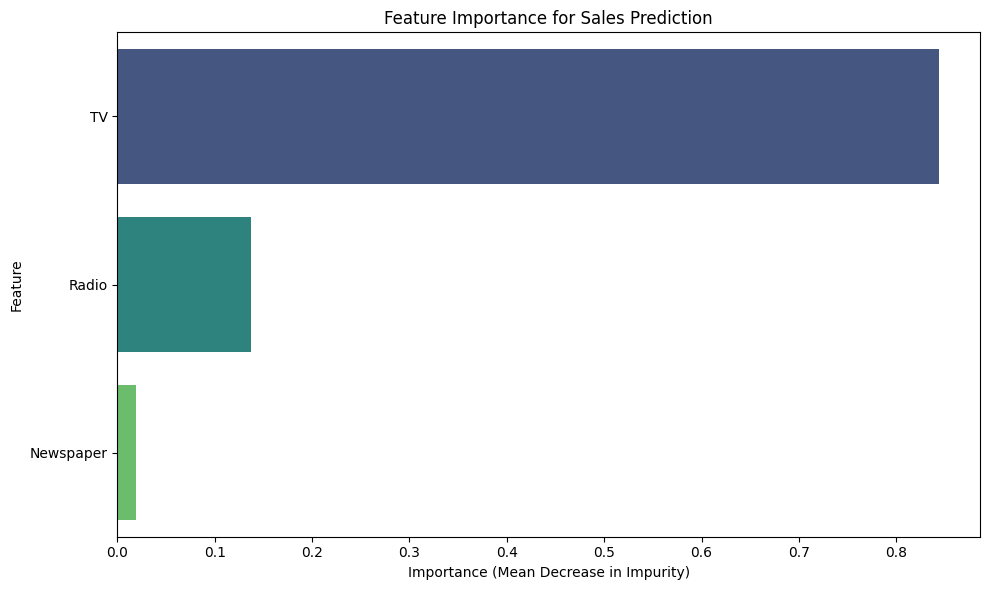

In [ ]:
feature_importances = final_model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("-Feature Importances-")
display(importance_df)

# Visualize feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance for Sales Prediction')
plt.xlabel('Importance (Mean Decrease in Impurity)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [ ]:
model_filename = 'extra_trees_regressor_model.joblib'
scaler_filename = 'standard_scaler.joblib'

joblib.dump(final_model, model_filename)
print(f"Optimized Extra Trees Regressor model saved as '{model_filename}'")

joblib.dump(scaler, scaler_filename)
print(f"StandardScaler saved as '{scaler_filename}'")

print("\nBoth model and scaler have been successfully saved to disk.")


Optimized Extra Trees Regressor model saved as 'extra_trees_regressor_model.joblib'
StandardScaler saved as 'standard_scaler.joblib'

Both model and scaler have been successfully saved to disk.


In [ ]:
loaded_model = joblib.load('extra_trees_regressor_model.joblib')
loaded_scaler = joblib.load('standard_scaler.joblib')

print("Model and scaler loaded successfully!")


Model and scaler loaded successfully!


In [ ]:
custom_data = pd.DataFrame({
    'TV': [150.0, 250.0, 50.0, 200.0, 10.0],
    'Radio': [20.0, 40.0, 5.0, 30.0, 1.0],
    'Newspaper': [10.0, 5.0, 2.0, 8.0, 0.5]
})

print("Custom input data:")
display(custom_data)


Custom input data:


,TV,Radio,Newspaper
0,150.0,20.0,10.0
1,250.0,40.0,5.0
2,50.0,5.0,2.0
3,200.0,30.0,8.0
4,10.0,1.0,0.5


In [ ]:
custom_data_scaled = loaded_scaler.transform(custom_data)
custom_data_scaled_df = pd.DataFrame(custom_data_scaled, columns=custom_data.columns)

print("Custom input data (scaled):")
display(custom_data_scaled_df)


Custom input data (scaled):


,TV,Radio,Newspaper
0,-0.000230,-0.194840,-0.989014
1,1.188058,1.160276,-1.237509
2,-1.188519,-1.211178,-1.386605
3,0.593914,0.482718,-1.088412
4,-1.663834,-1.482201,-1.461153


In [ ]:
predictions = loaded_model.predict(custom_data_scaled)
custom_predictions_df = custom_data.copy()
custom_predictions_df['Predicted_Sales'] = predictions

print("-Predicted Sales for Custom Inputs-")
display(custom_predictions_df)


-Predicted Sales for Custom Inputs-


,TV,Radio,Newspaper,Predicted_Sales
0,150.0,20.0,10.0,2.878000
1,250.0,40.0,5.0,3.020333
2,50.0,5.0,2.0,2.878000
3,200.0,30.0,8.0,2.878000
4,10.0,1.0,0.5,2.878000


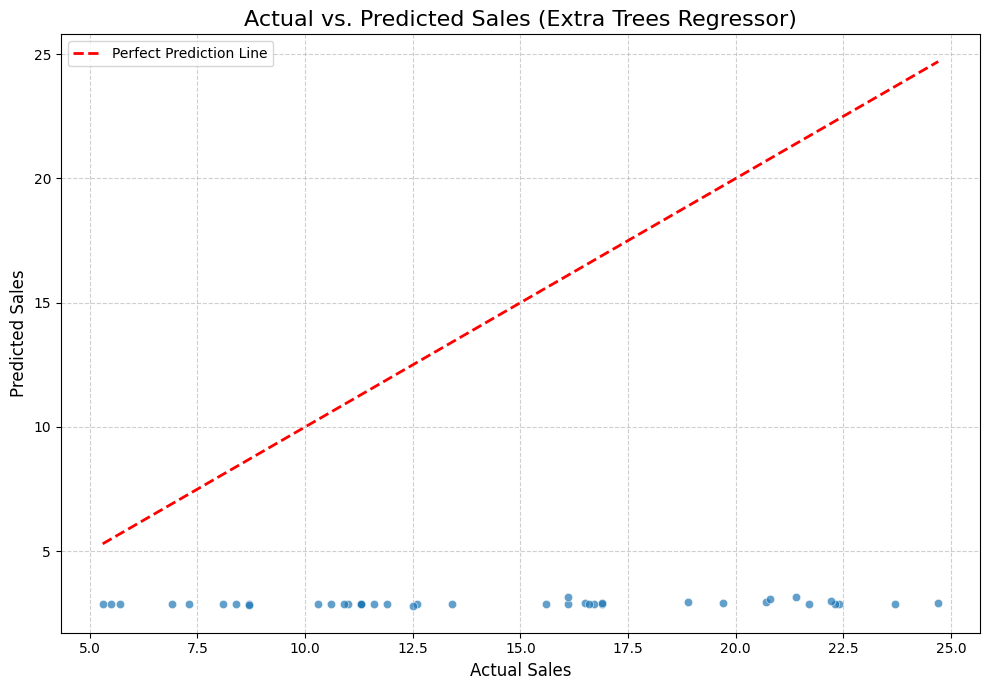

In [ ]:
y_pred_final = final_model.predict(X_test_scaled)
actual_vs_predicted = pd.DataFrame({'Actual Sales': y_test, 'Predicted Sales': y_pred_final})

plt.figure(figsize=(10, 7))
sns.scatterplot(x='Actual Sales', y='Predicted Sales', data=actual_vs_predicted, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2, label='Perfect Prediction Line')
plt.title('Actual vs. Predicted Sales (Extra Trees Regressor)', fontsize=16)
plt.xlabel('Actual Sales', fontsize=12)
plt.ylabel('Predicted Sales', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


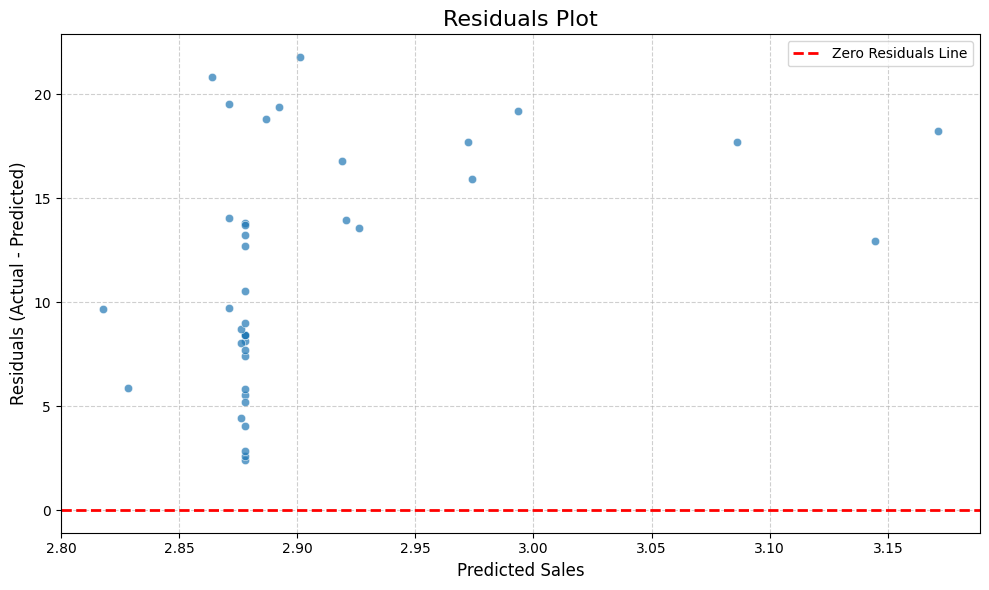

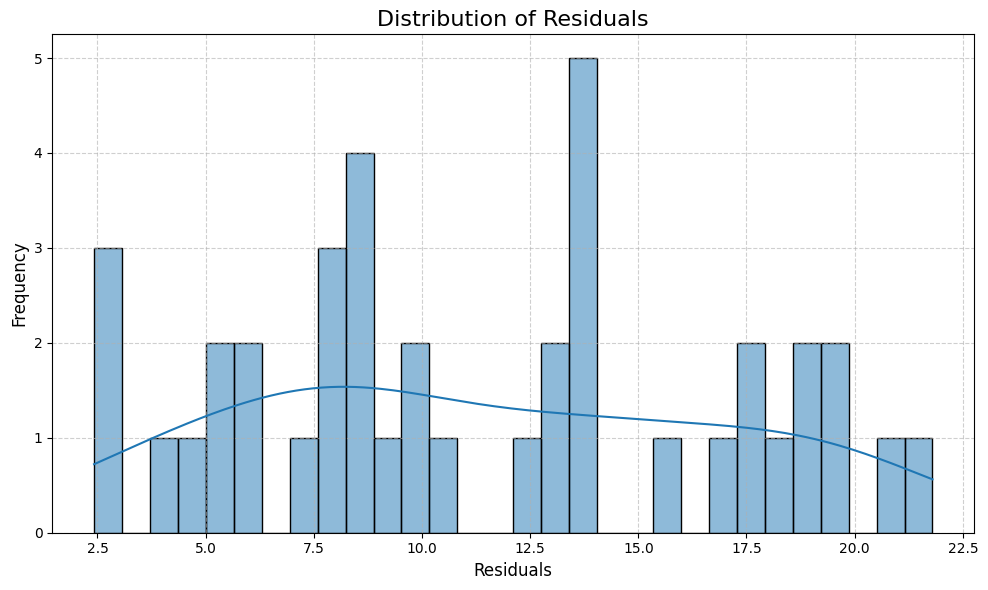

In [ ]:
# Calculate residuals
residuals = y_test - y_pred_final

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_final, y=residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', lw=2, label='Zero Residuals Line')
plt.title('Residuals Plot', fontsize=16)
plt.xlabel('Predicted Sales', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=30)
plt.title('Distribution of Residuals', fontsize=16)
plt.xlabel('Residuals', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
